In [155]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PowerTransformer, RobustScaler, QuantileTransformer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, LocallyLinearEmbedding
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import joblib
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score
import seaborn as sns


## Pipeline

### Preprocessing

PCA Visualization

In [93]:
data_path = 'Torgo_selected.csv'

In [94]:
torgo = pd.read_csv(data_path)

torgo_2 = torgo.copy()
y = torgo['label']
X = torgo.drop('label', axis=1)

In [95]:
torgo.isna().sum().sum()

np.int64(0)

In [134]:
# scaler = StandardScaler()
scaler = QuantileTransformer(output_distribution='normal')
X = scaler.fit_transform(X)

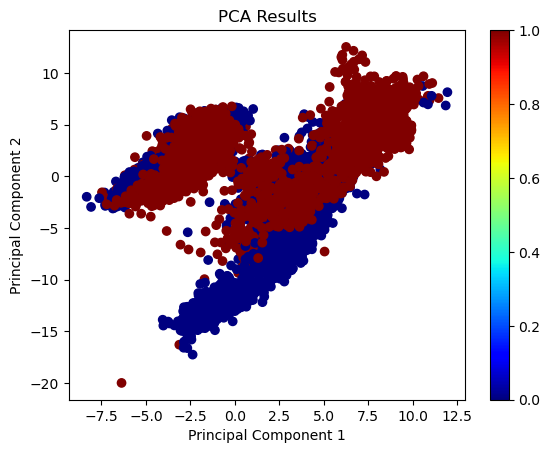

In [135]:
pca = PCA(n_components = 2, random_state=42)
X_pca = X.copy()
X_pca  = pca.fit_transform(X_pca)

plt.scatter(X_pca[: , 0], X_pca[: , 1], c=y.astype(int), cmap="jet")
plt.title("PCA Results")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar()
plt.show()

t-SNE Visualization

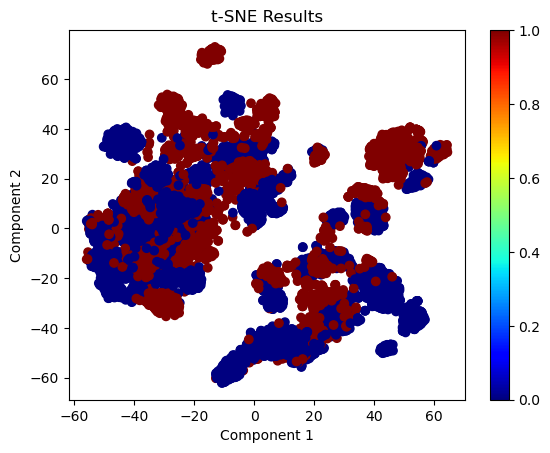

In [142]:
tsne = TSNE(n_components = 2, random_state=42, perplexity=100)
X_tsne = X.copy()
X_tsne = tsne.fit_transform(X_tsne)

plt.scatter(X_tsne[: , 0], X_tsne[: , 1], c=y.astype(int), cmap="jet")
plt.title("t-SNE Results")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.colorbar()
plt.show()

Decide number of relevant components to 95% of relevant information

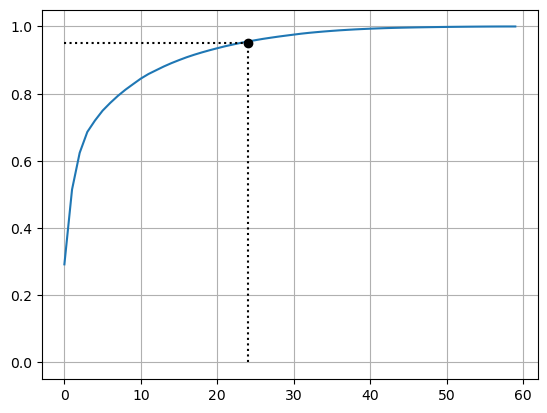

In [144]:
pca = PCA(random_state=42)

X_train_pca  = X.copy()
X_train_pca = pca.fit_transform(X_train_pca)
cumsum = np.cumsum(pca.explained_variance_ratio_)
n_components_pca = np.argmax(cumsum >= 0.95) + 1

plt.plot(cumsum)
plt.plot([n_components_pca, n_components_pca], [0, 0.95], "k:")
plt.plot([0, n_components_pca], [0.95, 0.95], "k:")
plt.plot(n_components_pca, 0.95, "ko")
plt.grid()
plt.show()

Pipeline

In [151]:
pca = PCA(n_components=n_components_pca, random_state=42)
tsne = TSNE(n_components= 2 , random_state=42)

pca_pipeline = Pipeline([
    ('scaler', StandardScaler) ,
    ('pca', pca),
])
tsne_pipeline = Pipeline([{
    'scaler', RobustScaler(),
    'tsne', tsne
}])


## Training

In [145]:
Y = torgo['label']
X = torgo.drop('label', axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [153]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(random_state=42, n_jobs=-1)

model_pipeline = Pipeline ([
    ('preprocessing', pca_pipeline),
    ('forest', clf),
])

In [149]:
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint

param_grid = {
    'forest__n_estimators': [500, 700, 1000],
    'forest__max_depth': [40, 40, 60],
    'forest__max_features': ['sqrt', 'log2', None],
}

rnd_search = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=3,
    scoring='recall_macro',
    n_jobs=-1
)

rnd_search.fit(X_train, y_train)


ValueError: 
All the 81 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
81 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\blaze\anaconda3\envs\plap-wsi\Lib\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\blaze\anaconda3\envs\plap-wsi\Lib\site-packages\sklearn\base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\blaze\anaconda3\envs\plap-wsi\Lib\site-packages\sklearn\pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
  File "c:\Users\blaze\anaconda3\envs\plap-wsi\Lib\site-packages\sklearn\pipeline.py", line 588

In [ ]:
model = rnd_search.best_estimator_
rnd_search.best_params_

In [160]:
best_params = rnd_search.best_params_

AttributeError: 'GridSearchCV' object has no attribute 'best_params_'

In [ ]:
joblib.dump(rnd_search.best_params_, 'best_params.pkl')

{'forest__max_depth': 50,
 'forest__max_features': 'sqrt',
 'forest__n_estimators': 700}

In [106]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Visualization

In [ ]:
# StandardScaler
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))
print(recall_score(y_test, y_pred, average='macro'))
print(precision_score(y_test, y_pred, average='macro'))
print(f1_score(y_test, y_pred, average='macro'))


              precision    recall  f1-score   support

           0       0.93      0.99      0.96      2065
           1       0.96      0.84      0.90       894

    accuracy                           0.94      2959
   macro avg       0.95      0.91      0.93      2959
weighted avg       0.94      0.94      0.94      2959

[[2037   28]
 [ 145  749]]
0.9415343021290977
0.9121241421150419
0.9487555841817987
0.9278672719589298


<Axes: >

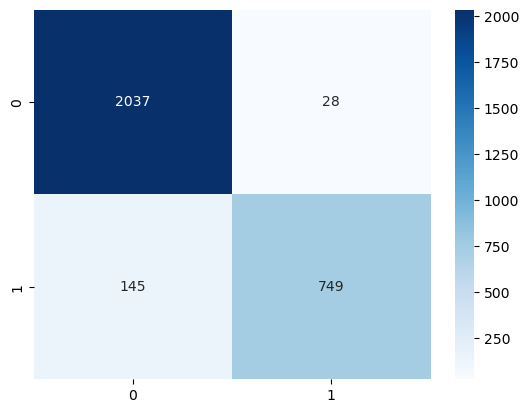

In [ ]:
# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap='Blues', fmt='d')

### Plotting one of the trees

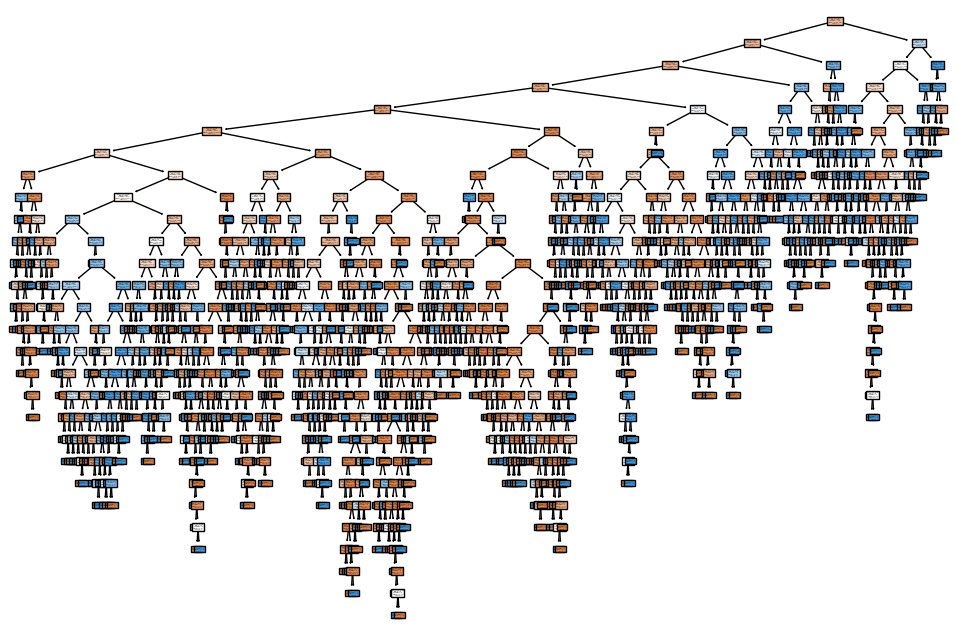

In [197]:
from sklearn.tree import plot_tree

tree_clf = model.named_steps['forest'][0]

plt.figure(figsize=(12, 8))
plot_tree(tree_clf,  feature_names=model.named_steps['preprocessing'].named_steps['pca'].get_feature_names_out(), class_names=[str(cls) for cls in y_train.unique()], filled=True)
plt.show()

In [154]:

joblib.dump(model, 'best_model.pkl')

['best_model.pkl']